# Loss Reserve And Risk Segmentation

This notebook is the third stage of the course project workflow. Run the notebooks in this order:
1. `exploratory_analysis.ipynb`
2. `model_comparison.ipynb`
3. `loss_reserve_segmentation.ipynb`

The objective here is to extend the temporal PD workflow into a course-aligned `PD x LGD x EAD` expected-loss view, a simplified CECL-style reserve snapshot, and management-facing risk segmentation.

## Workflow Scope

This notebook keeps the stage-2 champion fixed-horizon PD model for 12-month expected loss, adds a pooled-logistic hazard model for lifetime PD, estimates expected LGD with a credibility-weighted managerial lookup, and summarizes expected loss at both loan and segment level.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (
        candidate.resolve()
        for candidate in [Path.cwd(), Path.cwd().parent]
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the project root from the current notebook session.')

sys.path.append(str(PROJECT_ROOT / 'src'))

import copy
import json

import pandas as pd
from IPython.display import Markdown, display

from loss_reporting import write_loss_reserve_report
from loss_workflow import run_loss_reserve_workflow
from visualization import export_loss_reserve_visuals


## Locked Configuration

The stage-2 fixed-horizon PD component is intentionally locked to the already-selected champion configuration, while the hazard model still searches a small validation-only grid.

In [2]:
STAGE2_SCORING_CONFIG = {
    'processed_data_path': str(PROJECT_ROOT / 'data' / 'processed' / 'loan_clean.csv'),
    'random_state': 42,
    'sample_frac': 1.0,
    'temporal_split': {
        'train_end': '2016-01-01',
        'valid_end': '2017-01-01',
    },
    'enabled_models': ['hist_gradient_boosting'],
    'selected_model_key': 'hist_gradient_boosting',
    'feature_flags': {
        'use_additional_numeric_features': True,
        'use_engineered_features': True,
        'use_extended_engineered_features': True,
        'use_home_ownership_dummies': True,
        'use_purpose_dummies': True,
        'use_fico_bucket_dummies': True,
        'use_verification_status_dummies': True,
        'use_grade_dummies': False,
        'use_initial_list_status_dummies': False,
        'use_application_type_dummies': False,
    },
    'meta_columns': ['sample_id', 'issue_date', 'loan_amnt', 'annual_inc', 'fico_range_low', 'term_months', 'int_rate', 'revol_util'],
    'model_params': {
        'hist_gradient_boosting': {
            'early_stopping': False,
            'l2_regularization': 0.0,
            'learning_rate': 0.05,
            'max_depth': 6,
            'max_iter': 150,
            'max_leaf_nodes': 31,
            'min_samples_leaf': 50,
        }
    },
}

WORKFLOW_CONFIG = {
    'raw_data_path': str(PROJECT_ROOT / 'data' / 'raw' / 'accepted_2007_to_2018Q4.csv'),
    'pd_prediction_path': str(PROJECT_ROOT / 'data' / 'processed' / 'test_with_pd_best_model.csv'),
    'loss_workflow_path': str(PROJECT_ROOT / 'data' / 'processed' / 'loss_workflow_dataset.csv'),
    'charged_off_proxy_path': str(PROJECT_ROOT / 'data' / 'processed' / 'charged_off_loss_proxy.csv'),
    'cecl_snapshot_path': str(PROJECT_ROOT / 'data' / 'processed' / 'cecl_active_snapshot.csv'),
    'test_loss_metrics_path': str(PROJECT_ROOT / 'data' / 'processed' / 'test_with_loss_metrics.csv'),
    'segment_summary_path': str(PROJECT_ROOT / 'data' / 'processed' / 'segment_expected_loss_summary.csv'),
    'portfolio_summary_path': str(PROJECT_ROOT / 'data' / 'processed' / 'portfolio_expected_loss_summary.csv'),
    'report_output_path': str(PROJECT_ROOT / 'reports' / 'loss_reserve_segmentation_report.md'),
    'temporal_split': {
        'train_end': '2016-01-01',
        'valid_end': '2017-01-01',
    },
    'lgd_fit_splits': ['train', 'validation'],
    'lgd_shrinkage_k': 50,
    'hazard_param_grid': [
        {'C': 0.5, 'class_weight': None},
        {'C': 1.0, 'class_weight': None},
        {'C': 2.0, 'class_weight': 'balanced'},
    ],
    'stage2_scoring': STAGE2_SCORING_CONFIG,
}

print(json.dumps(WORKFLOW_CONFIG, indent=2))

{
  "raw_data_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/raw/accepted_2007_to_2018Q4.csv",
  "pd_prediction_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/test_with_pd_best_model.csv",
  "loss_workflow_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/loss_workflow_dataset.csv",
  "charged_off_proxy_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/charged_off_loss_proxy.csv",
  "cecl_snapshot_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/cecl_active_snapshot.csv",
  "test_loss_metrics_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/test_with_loss_metrics.csv",
  "segment_summary_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/segment_expected_loss_summary.csv",
  "portfolio_summary_path": "/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/proc

## Run The Full Loss Workflow

The workflow writes all processed outputs and the Markdown report as part of the execution.

In [3]:
loss_result = run_loss_reserve_workflow(copy.deepcopy(WORKFLOW_CONFIG))
workflow_result = loss_result['workflow_result']
print(f"Report written to: {loss_result['report_path']}")
print(f"Resolved holdout rows: {len(loss_result['resolved_holdout']):,}")
print(f"Active snapshot rows: {len(loss_result['active_snapshot']):,}")

Report written to: /Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/reports/loss_reserve_segmentation_report.md
Resolved holdout rows: 225,611
Active snapshot rows: 912,609


## Dataset, Hazard, Expected-Loss, And Diagnostic Summaries

,split_label,loan_status,loan_count,funded_amount,avg_months_on_book
0,test,Charged Off,48015,7.698271e+08,8.933080
1,test,Current,689032,1.084789e+10,12.457195
2,test,Default,28,4.105750e+05,17.000000
3,test,Fully Paid,177596,2.489342e+09,9.423776
4,test,In Grace Period,5830,1.021183e+08,13.962264
5,test,Late (16-30 days),3095,5.346318e+07,13.183522
6,test,Late (31-120 days),15225,2.581706e+08,12.735568
7,train,Charged Off,152302,2.356932e+09,18.829337
8,train,Current,55224,1.112566e+09,45.995817
9,train,Default,2,4.700000e+04,47.000000


,split_label,panel_cells,exposure_count,event_count
0,test,3755,10996348,46877
1,train,4590,23264938,151644
2,validation,4094,9771937,67725


,candidate_id,params,validation_lifetime_auc,validation_lifetime_ks,validation_lifetime_brier,validation_12m_auc,validation_12m_brier,validation_rank
0,1,"{'C': 0.5, 'class_weight': None}",0.694316,0.279747,0.162787,0.693925,0.089174,1
1,3,"{'C': 2.0, 'class_weight': 'balanced'}",0.694310,0.279747,0.167367,0.693919,0.087322,2
2,2,"{'C': 1.0, 'class_weight': None}",0.694310,0.279747,0.162788,0.693919,0.089172,3


,split_name,pd_measure,auc,ks,brier
0,validation,lifetime,0.694316,0.279747,0.162787
1,validation,12m,0.693925,0.281929,0.089174


,split_name,pd_measure,auc,ks,brier
0,test,lifetime,0.682992,0.268525,0.155404
1,test,12m,0.670706,0.254790,0.138009


,analysis_scope,pd_measure,loan_count,funded_amount,avg_pd,avg_lgd,avg_ead,avg_el,total_el,portfolio_el_share,actual_loss_amount,actual_loss_rate
0,resolved_test,12m,225611,3.259169e+09,0.205696,0.901141,14445.965955,2959.921871,6.677909e+08,1.0,6.162652e+08,0.189087
1,resolved_test,lifetime,225611,3.259169e+09,0.235686,0.901141,14445.965955,3242.060013,7.314444e+08,1.0,6.162652e+08,0.189087
2,active_snapshot,12m,912609,1.459190e+10,0.205730,0.904843,10467.686181,2136.515632,1.949803e+09,1.0,NaN,NaN
3,active_snapshot,lifetime,912609,1.459190e+10,0.142539,0.904843,10467.686181,1643.974240,1.500306e+09,1.0,NaN,NaN


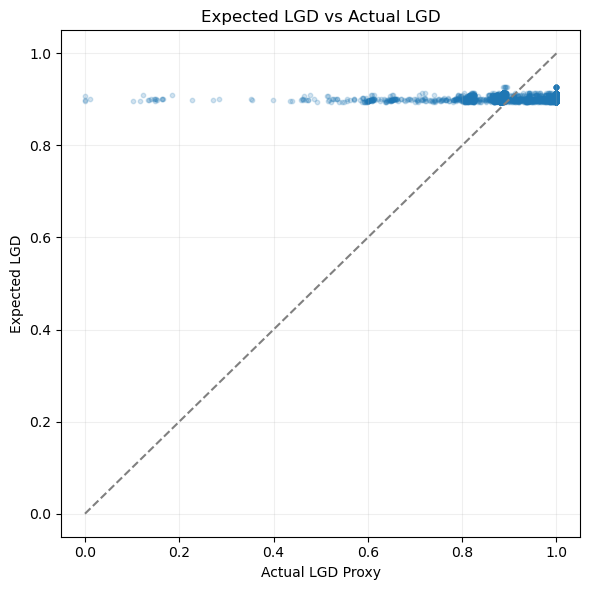

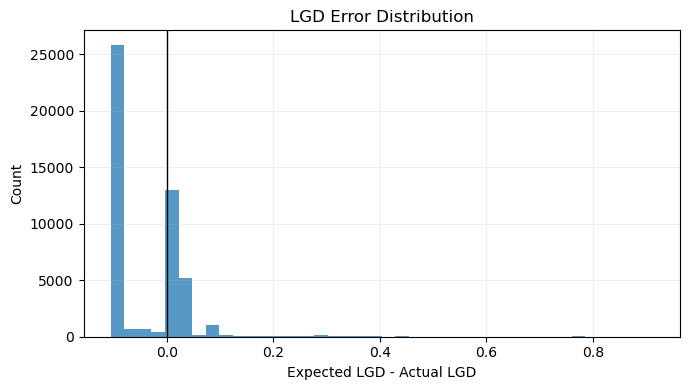

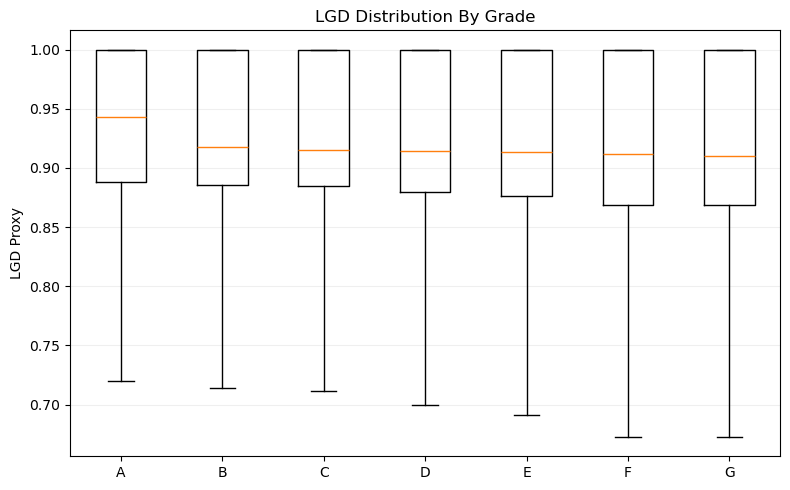

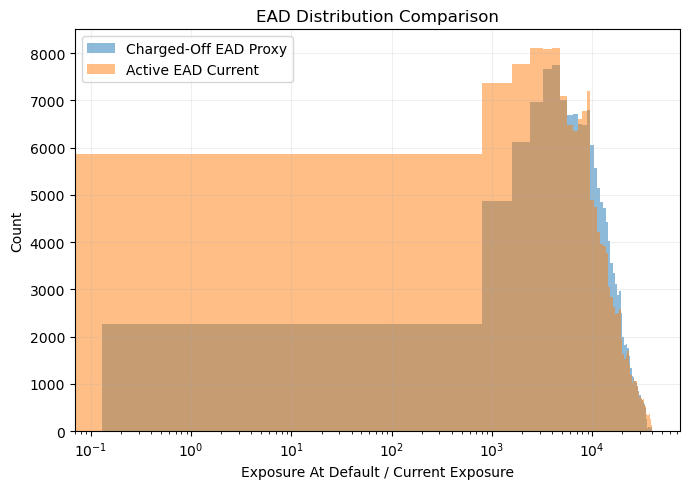

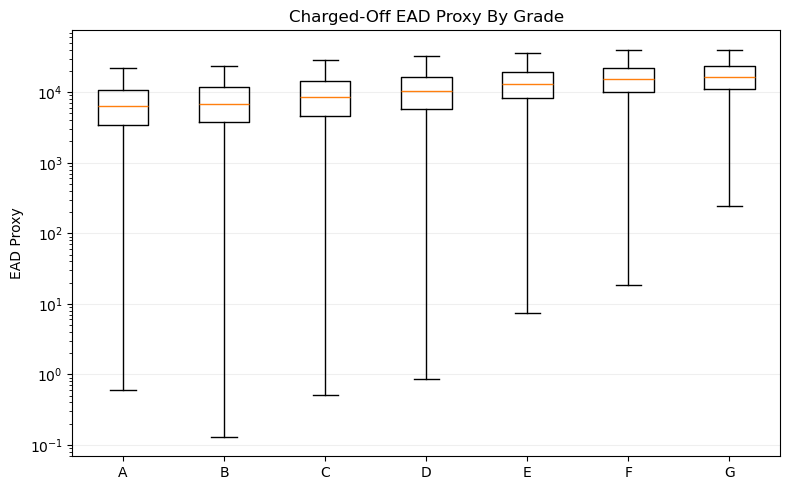

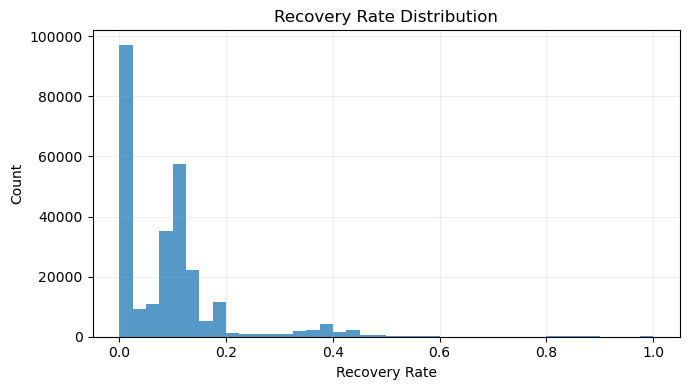

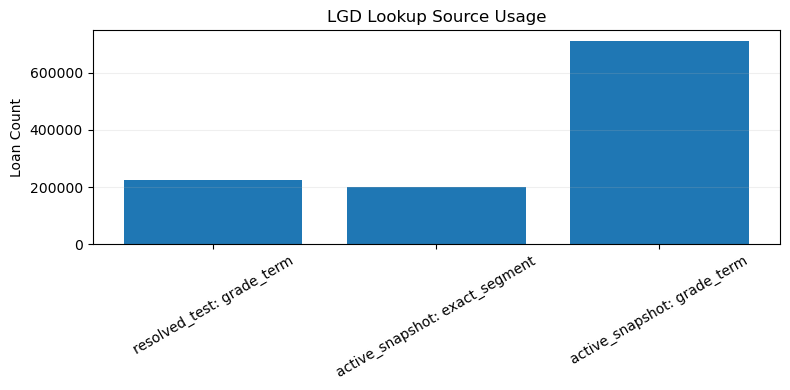

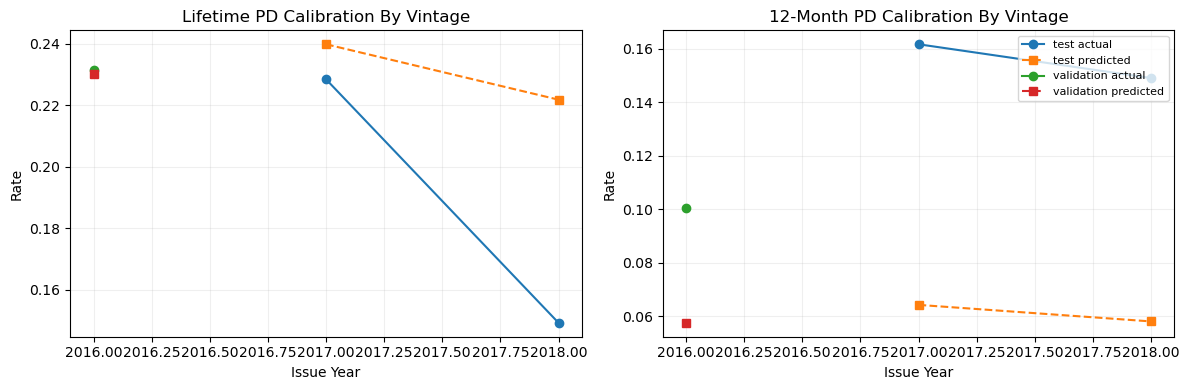

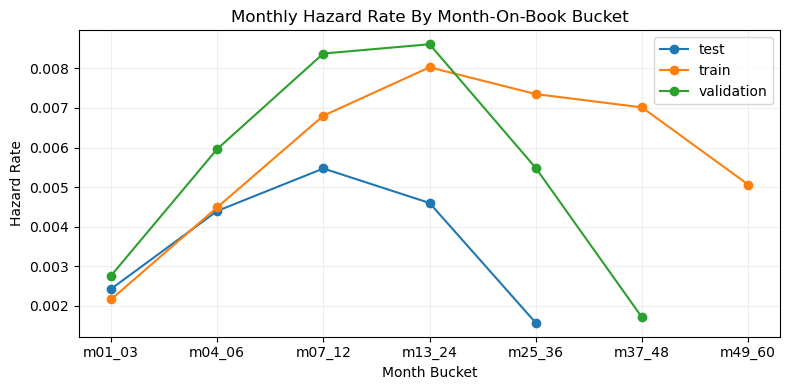

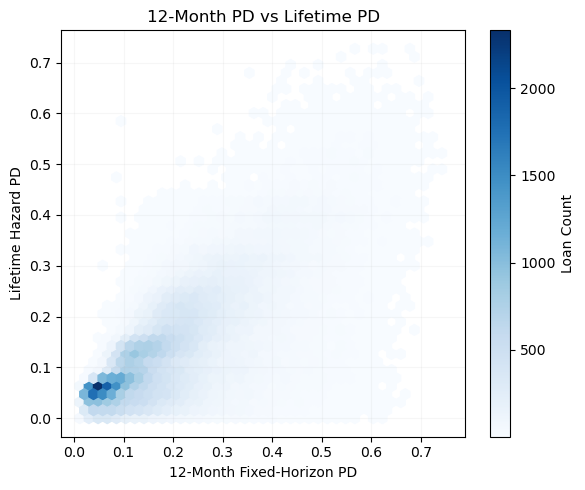

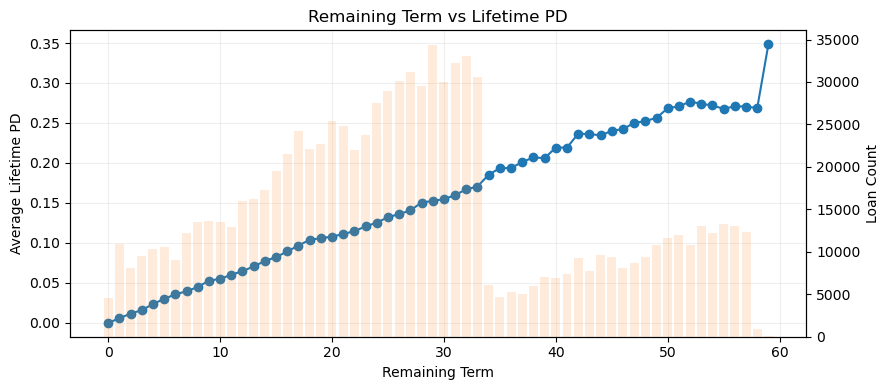

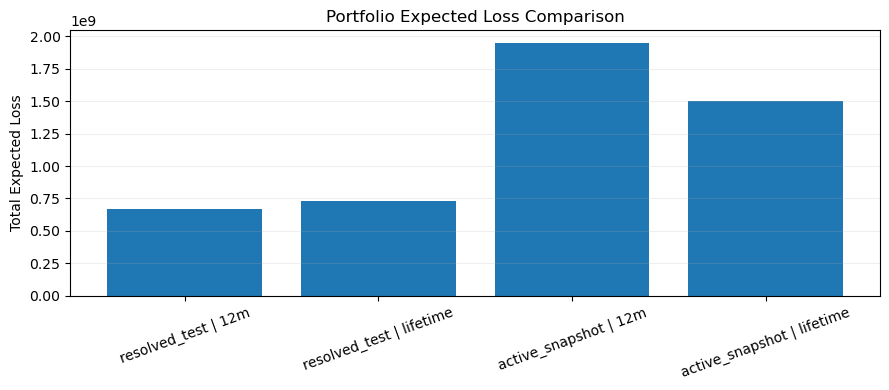

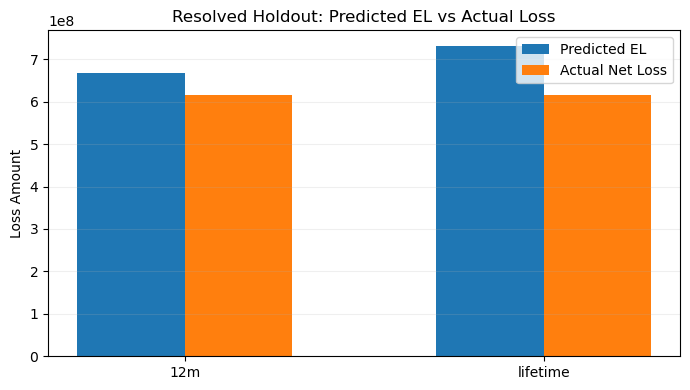

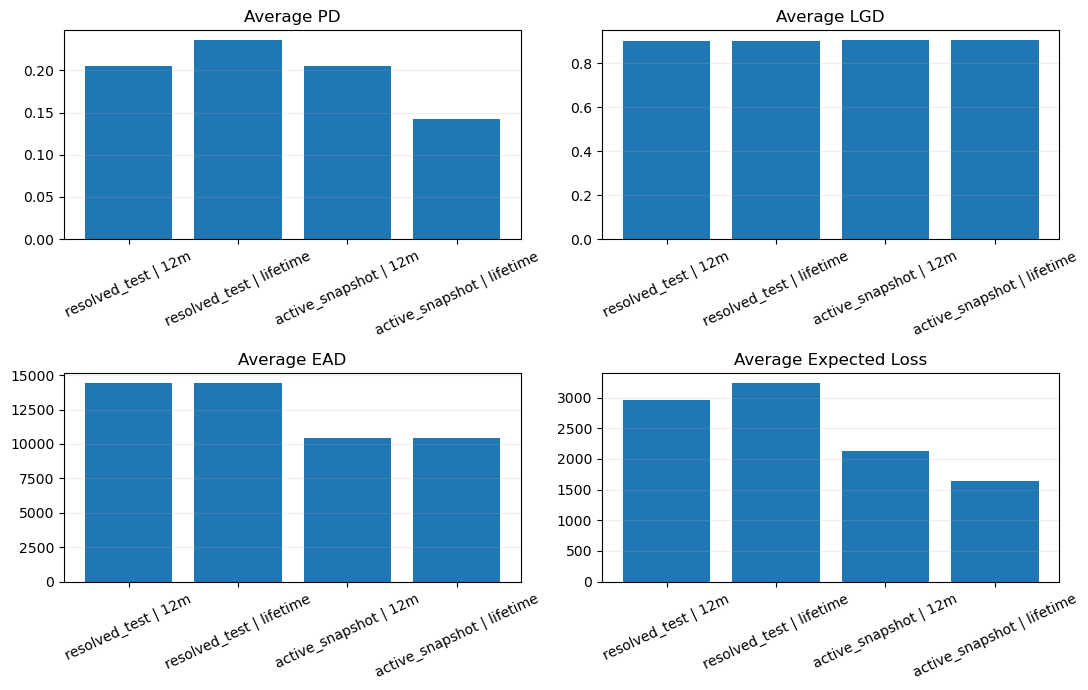

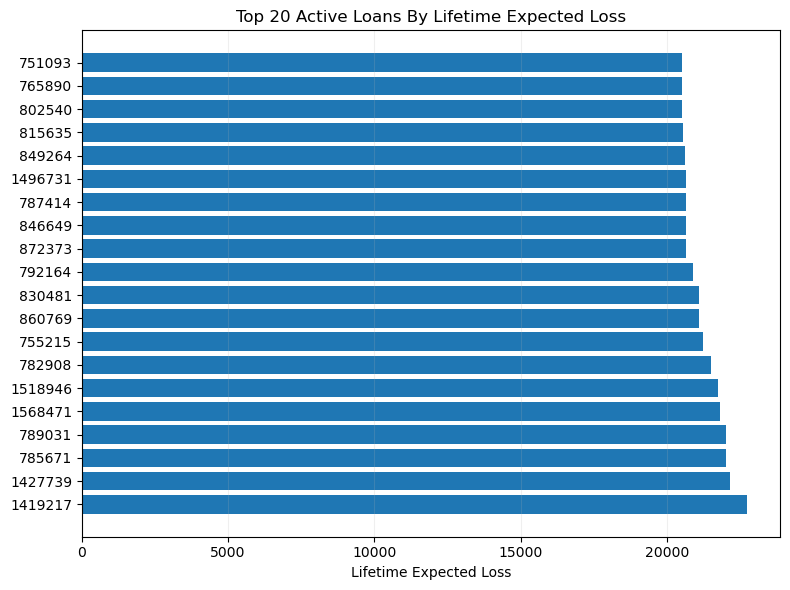

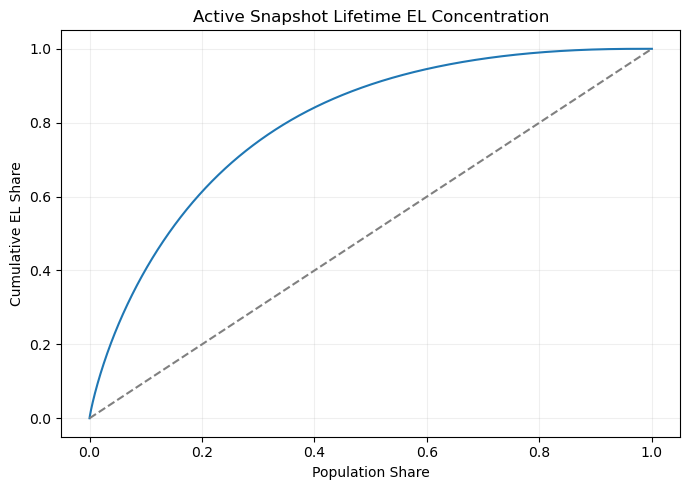

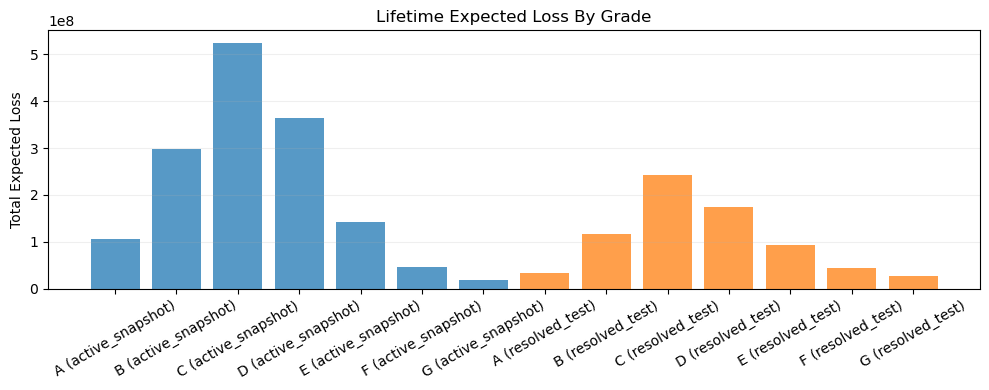

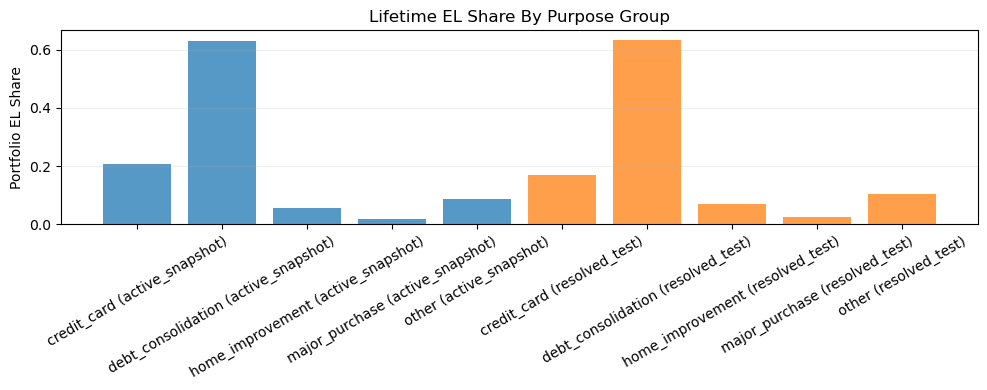

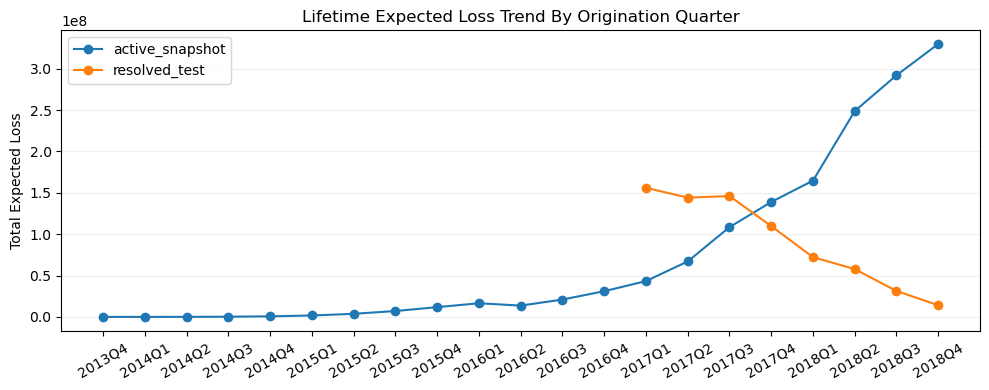

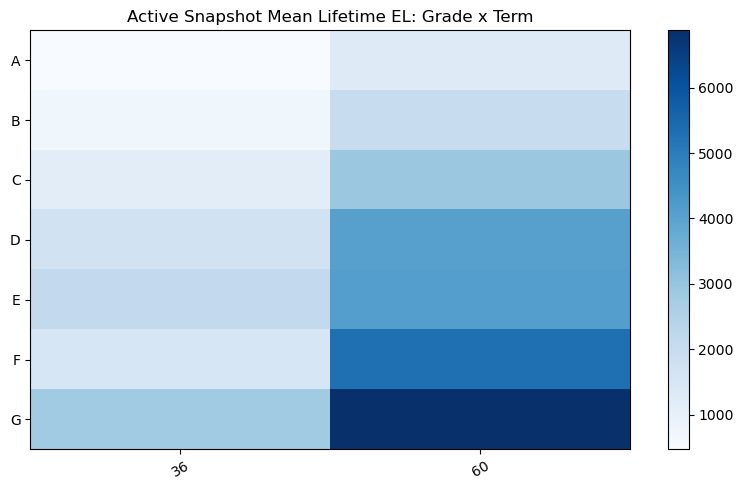

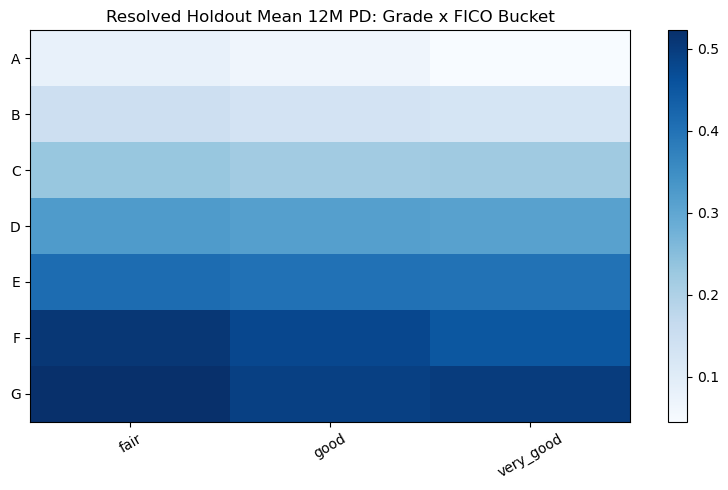

,rows,mae,rmse,bias,correlation,avg_expected_lgd,avg_actual_lgd
0,48015,0.069229,0.089174,-0.040536,0.00306,0.901118,0.941654


,scope,rows,mean,median,p90,max
0,charged_off_ead_proxy,268537,11170.097332,9502.73,22507.592,40000.0
1,resolved_holdout_ead_reference,225611,14445.965955,12000.00,30000.000,40000.0
2,active_snapshot_ead_current,912609,10467.686181,8390.51,22878.280,40000.0


,rows,mean_recovery_rate,median_recovery_rate,p90_recovery_rate,mean_net_recoveries
0,268537,0.091366,0.084576,0.18044,1008.012938


,analysis_scope,pd_measure,top_n,top_el_share
0,resolved_test,lifetime,10,0.000346
1,resolved_test,lifetime,100,0.003122
2,resolved_test,lifetime,1000,0.026149
3,active_snapshot,lifetime,10,0.000145
4,active_snapshot,lifetime,100,0.001300
5,active_snapshot,lifetime,1000,0.010301


Visual report written to: /Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/reports/loss_reserve_segmentation_report.md


,visual,path
0,active_pd_compare,/Users/minleihao/Desktop/Risk Project/IDS583_F...
1,ead_by_grade,/Users/minleihao/Desktop/Risk Project/IDS583_F...
2,ead_distribution,/Users/minleihao/Desktop/Risk Project/IDS583_F...
3,el_component_summary,/Users/minleihao/Desktop/Risk Project/IDS583_F...
4,el_concentration_curve,/Users/minleihao/Desktop/Risk Project/IDS583_F...
5,grade_fico_heatmap,/Users/minleihao/Desktop/Risk Project/IDS583_F...
6,grade_term_heatmap,/Users/minleihao/Desktop/Risk Project/IDS583_F...
7,hazard_vintage_calibration,/Users/minleihao/Desktop/Risk Project/IDS583_F...
8,lgd_actual_vs_expected,/Users/minleihao/Desktop/Risk Project/IDS583_F...
9,lgd_by_grade,/Users/minleihao/Desktop/Risk Project/IDS583_F...


In [4]:
display(workflow_result['loss_dataset_summary'])
display(workflow_result['hazard_panel_summary'])
display(workflow_result['hazard_search_table'])
display(workflow_result['hazard_validation_overall'])
display(workflow_result['hazard_test_overall'])
display(workflow_result['portfolio_summary'])

loss_visual_artifacts = export_loss_reserve_visuals(
    loss_result,
    output_dir=PROJECT_ROOT / 'reports' / 'figures' / 'loss_reserve',
    show=True,
)
display(loss_visual_artifacts['tables']['lgd_diagnostics'])
display(loss_visual_artifacts['tables']['ead_summary'])
display(loss_visual_artifacts['tables']['recovery_summary'])
display(loss_visual_artifacts['tables']['el_concentration'])

visual_report_path = write_loss_reserve_report(
    workflow_result,
    WORKFLOW_CONFIG,
    WORKFLOW_CONFIG['report_output_path'],
    visual_paths=loss_visual_artifacts['paths'],
    diagnostic_tables=loss_visual_artifacts['tables'],
)
print(f'Visual report written to: {visual_report_path}')
visual_map = pd.DataFrame(
    [{'visual': key, 'path': str(path)} for key, path in loss_visual_artifacts['paths'].items()]
).sort_values('visual').reset_index(drop=True)
display(visual_map)

## Management-Facing Segment Views And Heatmaps

In [5]:
segment_summary = loss_result['segment_summary'].copy()
top_segments = (
    segment_summary
    .sort_values(['analysis_scope', 'pd_measure', 'total_el'], ascending=[True, True, False])
    .groupby(['analysis_scope', 'pd_measure', 'segment_type'], as_index=False)
    .head(3)
    .reset_index(drop=True)
)
display(top_segments)

,segment_value,loan_count,funded_amount,avg_pd,avg_lgd,avg_ead,avg_el,total_el,segment_type,analysis_scope,pd_measure,portfolio_el_share
0,60,326036,6.904184e+09,0.303625,0.911553,14972.378621,4061.473345,1.324187e+09,term_months,active_snapshot,12m,0.679138
1,debt_consolidation,496456,8.506278e+09,0.222213,0.905144,11238.390989,2434.235708,1.208491e+09,purpose_group,active_snapshot,12m,0.619801
2,fair,482110,7.207720e+09,0.250610,0.904131,9518.560306,2419.220216,1.166330e+09,fico_bucket,active_snapshot,12m,0.598178
3,2018,438931,7.098279e+09,0.194120,0.902765,13579.496927,2600.862116,1.141599e+09,issue_year,active_snapshot,12m,0.585494
4,50-100k,446013,7.067912e+09,0.206771,0.905129,10317.281094,2209.640602,9.855284e+08,annual_income_band,active_snapshot,12m,0.505450
...,...,...,...,...,...,...,...,...,...,...,...,...
73,100-150k,35064,6.764648e+08,0.203040,0.902047,19292.286961,3780.772833,1.325690e+08,annual_income_band,resolved_test,lifetime,0.181243
74,credit_card,43671,6.240337e+08,0.206665,0.901347,14289.430057,2815.333403,1.229484e+08,purpose_group,resolved_test,lifetime,0.168090
75,B,62229,8.310788e+08,0.155434,0.901961,13355.169214,1865.461689,1.160858e+08,grade,resolved_test,lifetime,0.158708
76,other,33800,3.589132e+08,0.222290,0.900220,10618.735207,2236.404156,7.559046e+07,purpose_group,resolved_test,lifetime,0.103344


## Validation Checks

These assertions enforce the temporal split rule, proxy bounds, and expected-loss arithmetic used in the report.

In [6]:
workflow_df = loss_result['workflow_df']
resolved_holdout = loss_result['resolved_holdout']
active_snapshot = loss_result['active_snapshot']
charged_off_proxy = loss_result['charged_off_proxy']
portfolio_summary = loss_result['portfolio_summary']

train_dates = workflow_df.loc[workflow_df['split_label'] == 'train', 'issue_date']
validation_dates = workflow_df.loc[workflow_df['split_label'] == 'validation', 'issue_date']
test_dates = workflow_df.loc[workflow_df['split_label'] == 'test', 'issue_date']

assert train_dates.max() < validation_dates.min()
assert validation_dates.max() < test_dates.min()
assert workflow_df['sample_id'].nunique() == len(workflow_df)
assert charged_off_proxy['ead_proxy'].ge(0).all()
assert charged_off_proxy['lgd_proxy'].between(0, 1).all()
assert active_snapshot['ead_current'].ge(0).all()
assert active_snapshot['lifetime_pd_hazard'].between(0, 1).all()
assert resolved_holdout['pd_12m_fixed_horizon'].between(0, 1).all()
assert (resolved_holdout['expected_loss_12m'].round(10) == (resolved_holdout['pd_12m_fixed_horizon'] * resolved_holdout['expected_lgd'] * resolved_holdout['ead_reference']).round(10)).all()
assert (active_snapshot['lifetime_expected_loss'].round(10) == (active_snapshot['lifetime_pd_hazard'] * active_snapshot['expected_lgd'] * active_snapshot['ead_current']).round(10)).all()
portfolio_by_scope = portfolio_summary.groupby('analysis_scope', as_index=False)['total_el'].sum()
display(portfolio_by_scope)
print('All temporal, bounds, and accounting checks passed.')

,analysis_scope,total_el
0,active_snapshot,3.450109e+09
1,resolved_test,1.399235e+09


All temporal, bounds, and accounting checks passed.


## Output Locations

In [7]:
output_map = pd.DataFrame(
    [
        {'asset': key, 'path': value}
        for key, value in WORKFLOW_CONFIG.items()
        if key.endswith('_path')
    ]
)
display(output_map)

report_preview = Path(WORKFLOW_CONFIG['report_output_path']).read_text(encoding='utf-8').splitlines()[:30]
display(Markdown('```markdown\n' + '\n'.join(report_preview) + '\n```'))

,asset,path
0,raw_data_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
1,pd_prediction_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
2,loss_workflow_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
3,charged_off_proxy_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
4,cecl_snapshot_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
5,test_loss_metrics_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
6,segment_summary_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
7,portfolio_summary_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...
8,report_output_path,/Users/minleihao/Desktop/Risk Project/IDS583_F...


```markdown
# Credit Loss, CECL Proxy, And Risk Segmentation Report

## Course Formula Alignment

This phase extends the stage-2 PD workflow into a course-aligned expected-loss framework.
The core lens is `Expected Loss = PD x LGD x EAD`, with installment-loan simplifications for EAD, credibility-weighted LGD lookups, a pooled-logistic hazard model for lifetime PD, and management-facing segmentation.
Pricing and economic capital are not implemented here; the report ends with a short bridge showing how these outputs feed those later modules.

## Data Assets And Temporal Policy

- Stage-2 PD benchmark path: `/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/test_with_pd_best_model.csv`
- Loss workflow dataset path: `/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/loss_workflow_dataset.csv`
- Charged-off LGD/EAD proxy path: `/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/charged_off_loss_proxy.csv`
- Active reserve snapshot path: `/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/cecl_active_snapshot.csv`
- Holdout loss evaluation path: `/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/test_with_loss_metrics.csv`
- Segment summary path: `/Users/minleihao/Desktop/Risk Project/IDS583_Final_Project/data/processed/segment_expected_loss_summary.csv`

The temporal split remains origination-based throughout the workflow: train vintages before 2016, validation vintages in 2016, and test vintages from 2017 onward.

### Workflow Dataset Summary

| split_label | loan_status | loan_count | funded_amount | avg_months_on_book |
| --- | --- | --- | --- | --- |
| test | Charged Off | 48015 | 769827075.0 | 8.933080188578622 |
| test | Current | 689032 | 10847888775.0 | 12.457195021421356 |
| test | Default | 28 | 410575.0 | 17.0 |
| test | Fully Paid | 177596 | 2489341750.0 | 9.423776436406225 |
| test | In Grace Period | 5830 | 102118275.0 | 13.962264150943396 |
| test | Late (16-30 days) | 3095 | 53463175.0 | 13.183521809369951 |
| test | Late (31-120 days) | 15225 | 258170600.0 | 12.735568339615156 |
```